# Fouling, heat recovery and pressure loss in a feed preheater

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/codex/3718-fouling-preheater/notebooks/process/fouling_thermal_hydraulic_preheater.ipynb)

A fixed exchanger can lose heating capacity while its flow resistance increases. This notebook
connects those effects using native NeqSim geometry, transport properties, enthalpy flashes and
`ProcessSystem` equipment. It demonstrates the functionality developed for
[equinor/neqsim #3718](https://github.com/equinor/neqsim/issues/3718).

**Learn to:** distinguish prescribed fouling resistance from a deposit layer; rate fixed geometry;
check duty and pressure constraints; quantify the downstream heating penalty; and validate the
calculation with analytical conduction and laminar-flow references.

The fluid and geometry below are synthetic public teaching inputs. This is a paper-inspired
capability demonstration, not a reproduction of the paper's Aspen cases.

## Evidence and model boundaries

Soylu and Demirel's 2025 paper examines fouling in a shell-and-tube preheater upstream of distillation:
[DOI 10.1115/1.4068191](https://doi.org/10.1115/1.4068191). The complete case compositions, geometry,
flow rates and deposit inputs were unavailable for this work. We therefore do not calibrate to its
abstract results or claim agreement with Aspen or experimental data.

Here the exchanger uses single-phase SRK hydrocarbon streams, inlet transport properties,
enthalpy-based heat-capacity secants and the existing **ideal counterflow effectiveness** relation.
Shell-and-tube geometry supplies film coefficients and hydraulic losses; detailed TEMA multipass
thermal corrections, deposit roughness, shell blockage and phase-change heat transfer are outside
this model. A trim heater delivers a specified final feed state. Its duty is the additional feed
heating requirement, **not a separately solved column reboiler duty**.

The time example is a sequence of steady states with an assumed deposit-growth schedule. It does
not solve deposition kinetics or the exchanger's transient thermal inventory.

## 1. Install and load the exact NeqSim source

Run in a fresh Colab runtime with Java 17 or later. The first build takes several minutes.
The notebook pins the feature commit and verifies the origin of the loaded Java classes.
For a prepared local workspace, `NEQSIM_SOURCE_DIR` may point to the same exact Git revision;
`NEQSIM_PREBUILT=1` reuses its previously compiled classes and dependency classpath.

In [1]:
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys

requirements = {
    "jpype": "JPype1==1.7.1",
    "numpy": "numpy==2.3.5",
    "pandas": "pandas==2.2.3",
    "matplotlib": "matplotlib==3.10.8",
}
missing = [package for module, package in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
NEQSIM_SOURCE_REF = "4317d3d1249d9eb20fc80fbb5fed2d6b6d388d48"
source_dir = Path(os.environ.get("NEQSIM_SOURCE_DIR", "/content/neqsim-fouling-source"))
if not (source_dir / ".git").exists():
    subprocess.run(
        ["git", "clone", "--quiet", "--filter=blob:none", "--no-checkout",
         "https://github.com/equinor/neqsim.git", str(source_dir)],
        check=True,
    )
    subprocess.run(["git", "checkout", "--quiet", NEQSIM_SOURCE_REF],
                   cwd=source_dir, check=True)
source_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=source_dir, text=True,
).strip()
assert source_commit == NEQSIM_SOURCE_REF, "Source revision differs from the validated feature"
assert not subprocess.check_output(
    ["git", "diff", "--", "src/main", "pom.xml"], cwd=source_dir, text=True,
).strip(), "Production source has uncommitted changes"

if os.environ.get("NEQSIM_PREBUILT") != "1":
    build = subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "compile", "dependency:build-classpath",
         "-Dmdep.outputFile=target/notebook-classpath.txt"],
        cwd=source_dir, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    if build.returncode:
        print(build.stdout)
        raise RuntimeError("NeqSim source build failed")

import jpype

assert not jpype.isJVMStarted(), "Restart the runtime to load the pinned source"
classes = source_dir / "target/classes"
dependencies = (source_dir / "target/notebook-classpath.txt").read_text().strip()
for entry in [str(classes), *dependencies.split(os.pathsep)]:
    jpype.addClassPath(entry)
jpype.startJVM("-Xmx2g", convertStrings=True)
jneqsim = jpype.JPackage("neqsim")
HeatExchanger = jpype.JClass("neqsim.process.equipment.heatexchanger.HeatExchanger")
ThermalCalculator = jpype.JClass(
    "neqsim.process.mechanicaldesign.heatexchanger.ThermalDesignCalculator"
)
origin = str(HeatExchanger.class_.getProtectionDomain().getCodeSource().getLocation())
assert str(classes.resolve()) in origin
assert hasattr(ThermalCalculator(), "setTubeFoulingLayer")
print("NeqSim source:", source_commit)
print("Java classes:", origin)
print("Java:", jpype.JClass("java.lang.System").getProperty("java.version"))
print("Python:", sys.version.split()[0])
print("Packages:", {name: importlib.metadata.version(name)
                    for name in ["JPype1", "numpy", "pandas", "matplotlib"]})

NeqSim source: 4317d3d1249d9eb20fc80fbb5fed2d6b6d388d48
Java classes: file:/workspace/scratch/f6f9de88e67f/neqsim-source/target/classes/
Java: 17.0.20
Python: 3.12.14
Packages: {'JPype1': '1.7.1', 'numpy': '2.3.5', 'pandas': '2.2.3', 'matplotlib': '3.10.8'}


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "axes.titleweight": "bold",
})
COLORS = {"heat": "#cf5c36", "cold": "#217a93", "deposit": "#8856a7", "clean": "#2d8b68"}
Stream = jneqsim.process.equipment.stream.Stream
Heater = jneqsim.process.equipment.heatexchanger.Heater
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
print("Native NeqSim stream, exchanger, thermal calculator and heater APIs loaded.")

Native NeqSim stream, exchanger, thermal calculator and heater APIs loaded.


## 2. A reusable fixed-geometry process

Both fluids contain 70 mol% n-heptane and 30 mol% n-octane with SRK and the classic mixing rule.
The cold tube feed enters at 30 °C and 8 kg/s; the hot shell stream enters at 110 °C and 10 kg/s.
Both inlet pressures are **20 bara**. The downstream heater targets 100 °C.

There are 100 tubes, two tube passes, 4 m per tube, a 20 mm nominal bore and 25 mm outside diameter.
The installed outside area is $A_o=\pi d_o L N$, where $L$ is tube length (m) and $N$ is tube count.
We explicitly zero the calculator's default fouling resistances to define the clean reference.

**Side mapping:** stream 0 is the tube side; stream 1 is the shell side. In this example, the cold
stream must be passed first. The native equipment and outlet streams remain available for reuse
in a larger process.

In [3]:
def make_preheater():
    fluid = jneqsim.thermo.system.SystemSrkEos(303.15, 20.0)
    fluid.addComponent("n-heptane", 0.7)
    fluid.addComponent("n-octane", 0.3)
    fluid.setMixingRule("classic")

    tube_feed = Stream("Cold tube feed", fluid)
    tube_feed.setFlowRate(8.0, "kg/sec")
    shell_feed = Stream("Hot shell stream", fluid.clone())
    shell_feed.setTemperature(110.0, "C")
    shell_feed.setFlowRate(10.0, "kg/sec")

    calculator = ThermalCalculator()
    calculator.setTubeIDm(0.020)
    calculator.setTubeODm(0.025)
    calculator.setTubePitchm(0.032)
    calculator.setTubeCount(100)
    calculator.setTubePasses(2)
    calculator.setTubeLengthm(4.0)
    calculator.setShellIDm(0.5)
    calculator.setBaffleSpacingm(0.2)
    calculator.setBaffleCount(10)
    calculator.setTubeWallConductivity(52.0)
    calculator.setFoulingTube(0.0)
    calculator.setFoulingShell(0.0)

    exchanger = HeatExchanger("Feed preheater", tube_feed, shell_feed)
    exchanger.setRatingCalculator(calculator)
    exchanger.setRatingArea(calculator.getOutsideHeatTransferArea())
    exchanger.setFlowArrangement("concentric tube counterflow")
    exchanger.setUseRatingPressureDrop(True)

    trim_heater = Heater("Feed trim heater", exchanger.getOutStream(0))
    trim_heater.setOutTemperature(100.0, "C")
    process = ProcessSystem()
    for equipment in [tube_feed, shell_feed, exchanger, trim_heater]:
        process.add(equipment)
    return process, exchanger, calculator, trim_heater

process, exchanger, calculator, trim_heater = make_preheater()
process.run()
print(f"Installed outside area: {exchanger.getRatingArea():.3f} m²")
print(f"Clean overall U: {calculator.getOverallU():.2f} W/(m² K)")
print(f"Equipment count: {len(process.getUnitOperations())}")

Installed outside area: 31.416 m²
Clean overall U: 431.54 W/(m² K)
Equipment count: 4


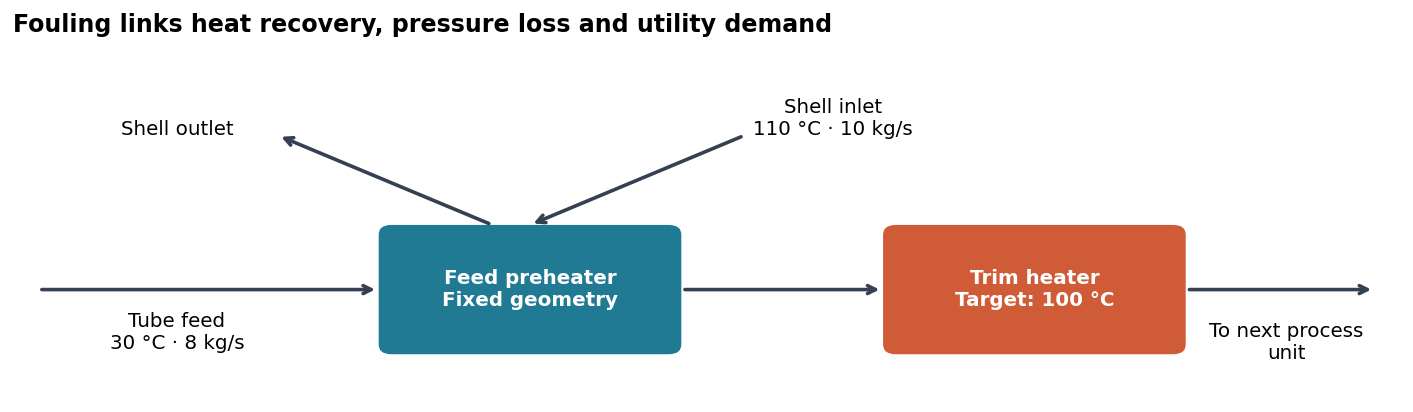

In [4]:
figure, axis = plt.subplots(figsize=(11, 3.3))
axis.set_xlim(0, 11)
axis.set_ylim(0, 3.4)
axis.axis("off")
for x, label, color in [(3.0, "Feed preheater\nFixed geometry", COLORS["cold"]),
                         (7.0, "Trim heater\nTarget: 100 °C", COLORS["heat"])]:
    axis.add_patch(FancyBboxPatch((x, 0.55), 2.2, 1.1, boxstyle="round,pad=0.1",
                                 facecolor=color, edgecolor="none"))
    axis.text(x + 1.1, 1.1, label, ha="center", va="center", color="white", weight="bold")
for start, end in [((0.2, 1.1), (2.9, 1.1)), ((5.3, 1.1), (6.9, 1.1)),
                   ((9.3, 1.1), (10.8, 1.1)), ((5.8, 2.65), (4.1, 1.75)),
                   ((3.8, 1.75), (2.1, 2.65))]:
    axis.annotate("", xy=end, xytext=start,
                  arrowprops={"arrowstyle": "->", "color": "#354052", "lw": 2})
axis.text(1.3, 0.5, "Tube feed\n30 °C · 8 kg/s", ha="center")
axis.text(6.5, 2.65, "Shell inlet\n110 °C · 10 kg/s", ha="center")
axis.text(1.3, 2.65, "Shell outlet", ha="center")
axis.text(10.1, 0.4, "To next process\nunit", ha="center")
axis.set_title("Fouling links heat recovery, pressure loss and utility demand", loc="left", pad=16)
plt.tight_layout()
plt.show()

The four native units preserve the connection from tube feed through preheater to trim heater.
The two exchanger streams exchange heat without mixing. Lower preheater duty changes the actual
trim-heater inlet enthalpy, so its extra demand is calculated by a subsequent NeqSim unit.

## 3. Deposit physics and analytical validation

For a deposit thickness $\delta$ (m), the remaining flow diameter is $d_f=d_i-2\delta>0$.
With deposit conductivity $k_f$ (W/(m K)), radial conduction gives:

$$R_{\mathrm{layer},o}=\frac{d_o}{2k_f}\ln\left(\frac{d_i}{d_f}\right)$$

This resistance is in m² K/W on the **nominal outside tube area**. The film contribution on the
same basis is $d_o/(d_f h_i)$, with $h_i$ in W/(m² K). The metal-wall resistance still uses the
nominal $d_i$ and $d_o$. See [MIT cylindrical conduction](https://web.mit.edu/course/16/16.unified/www/FALL/thermodynamics/notes/node119.html)
and [thermal resistances](https://web.mit.edu/16.unified/www/FALL/thermodynamics/notes/node123.html).

For an independent hydraulic check, choose a deliberately laminar fluid with fixed viscosity
$\mu$ (Pa s) and density $\rho$ (kg/m³). The Hagen–Poiseuille pressure loss for each flow path is
$32\mu L_{\mathrm{path}}v/d_f^2$. NeqSim adds 2.5 velocity heads per pass, so:

$$\Delta P=\frac{32\mu L_{\mathrm{path}}v}{d_f^2}+2.5N_p\frac{\rho v^2}{2}$$

Here $v$ is velocity in m/s, $N_p$ is pass count, and $L_{\mathrm{path}}=N_pL$ (m).
The check below uses a three-point analytical reference, not fitted values.

In [5]:
reference_rows = []
for thickness_mm in [0.0, 0.5, 1.0]:
    reference = ThermalCalculator()
    reference.setTubeIDm(0.020)
    reference.setTubeODm(0.025)
    reference.setTubeCount(100)
    reference.setTubePasses(2)
    reference.setTubeLengthm(4.0)
    reference.setTubePitchm(0.032)
    reference.setTubeSideFluid(850.0, 0.05, 2200.0, 0.13, 0.1, True)
    reference.setFoulingTube(0.0)
    reference.setFoulingShell(0.0)
    reference.setTubeFoulingLayer(thickness_mm / 1000.0, 0.2)
    reference.calculateStrict()
    diameter = 0.020 - 2.0 * thickness_mm / 1000.0
    velocity = 0.1 / (850.0 * 50 * np.pi * diameter**2 / 4.0)
    pressure_reference = 32 * 0.05 * 8.0 * velocity / diameter**2
    pressure_reference += 2.5 * 2 * 850.0 * velocity**2 / 2.0
    resistance_reference = 0.025 * np.log(0.020 / diameter) / (2.0 * 0.2)
    assert reference.getTubeSideRe() < 2300.0
    np.testing.assert_allclose(reference.getTubeSidePressureDrop(), pressure_reference, rtol=1e-12)
    np.testing.assert_allclose(reference.getTubeFoulingLayerResistanceOutside(),
                               resistance_reference, rtol=1e-12, atol=1e-15)
    reference_rows.append({
        "Layer [mm]": thickness_mm,
        "Bore [mm]": diameter * 1000.0,
        "Reference ΔP [Pa]": pressure_reference,
        "NeqSim ΔP [Pa]": reference.getTubeSidePressureDrop(),
        "Reference R [m² K/W]": resistance_reference,
        "NeqSim R [m² K/W]": reference.getTubeFoulingLayerResistanceOutside(),
    })
references = pd.DataFrame(reference_rows)
display(references.round(7))
print("PASS: three analytical conduction cases and three laminar hydraulic cases")

PASS: three analytical conduction cases and three laminar hydraulic cases


,Layer [mm],Bore [mm],Reference ΔP [Pa],NeqSim ΔP [Pa],Reference R [m² K/W],NeqSim R [m² K/W]
0,0.0,20.0,239.787822,239.787822,0.000000,0.000000
1,0.5,19.0,294.396540,294.396540,0.003206,0.003206
2,1.0,18.0,365.474503,365.474503,0.006585,0.006585


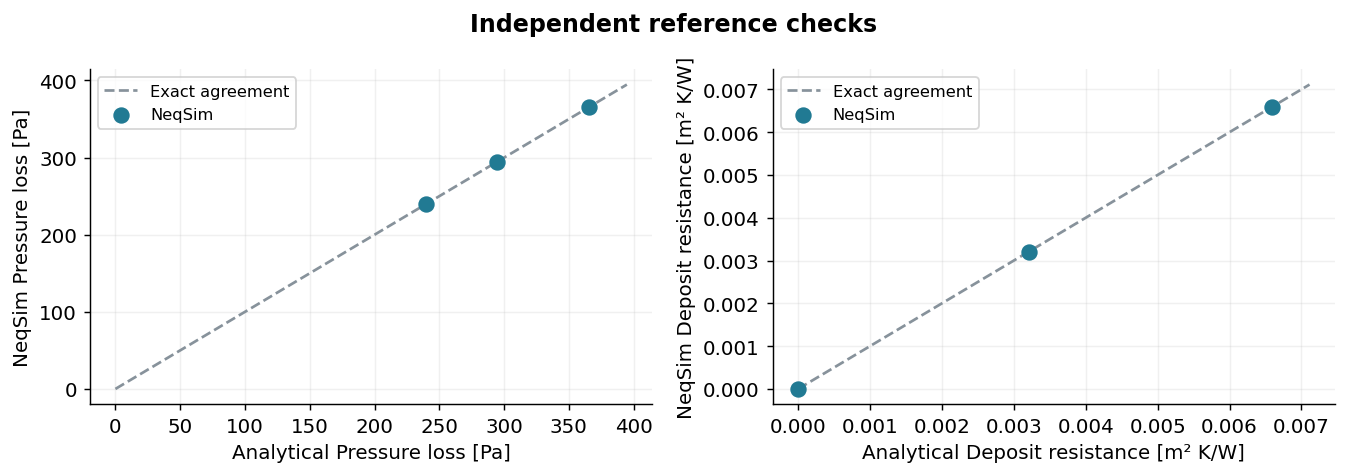

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
for axis, x, y, label in [
    (axes[0], "Reference ΔP [Pa]", "NeqSim ΔP [Pa]", "Pressure loss [Pa]"),
    (axes[1], "Reference R [m² K/W]", "NeqSim R [m² K/W]", "Deposit resistance [m² K/W]"),
]:
    values = references[x]
    axis.plot([0, values.max() * 1.08], [0, values.max() * 1.08], "--",
              color="#87929b", label="Exact agreement")
    axis.scatter(values, references[y], s=65, color=COLORS["cold"], zorder=3, label="NeqSim")
    axis.set_xlabel("Analytical " + label)
    axis.set_ylabel("NeqSim " + label)
    axis.legend(fontsize=9)
figure.suptitle("Independent reference checks", weight="bold")
plt.tight_layout()
plt.show()

All three points lie on the analytical parity lines within floating-point tolerance. This checks
the cylindrical area conversion and laminar hydraulic implementation. It does not validate the
turbulent or shell-side empirical correlations against experiments.

## 4. Compare clean, resistance-only and thickness-based fouling

We first increase prescribed tube resistance while retaining the nominal bore. We then increase
layer thickness at $k_f=0.2$ W/(m K). For a fair comparison, each resistance-only case receives the
same outside-area conduction resistance as its thickness-based counterpart, converted to the
nominal inner area. The layer case additionally updates velocity and film coefficient.

Positive duty below means recovered heat. Every result is obtained from a complete process rerun;
pressure loss is applied to the native exchanger outlet before the trim heater runs.

In [7]:
def snapshot(case, thickness_mm, model):
    heat_changes = []
    mass_errors = []
    component_errors = []
    for side in range(2):
        inlet = exchanger.getInStream(side).getThermoSystem()
        outlet = exchanger.getOutStream(side).getThermoSystem()
        pressure_drop = (calculator.getTubeSidePressureDropBar() if side == 0
                         else calculator.getShellSidePressureDropBar())
        np.testing.assert_allclose(outlet.getPressure(), inlet.getPressure() - pressure_drop,
                                   rtol=0.0, atol=1e-9)
        heat_changes.append(outlet.getEnthalpy() - inlet.getEnthalpy())
        mass_errors.append(abs(outlet.getFlowRate("kg/sec") - inlet.getFlowRate("kg/sec")))
        for component in range(inlet.getNumberOfComponents()):
            component_errors.append(abs(
                inlet.getComponent(component).getNumberOfmoles()
                - outlet.getComponent(component).getNumberOfmoles()
            ))
    return {
        "Case": case,
        "Model": model,
        "Layer [mm]": thickness_mm,
        "U [W/(m² K)]": calculator.getOverallU(),
        "Recovery [kW]": abs(exchanger.getDuty()) / 1000.0,
        "Tube outlet [°C]": exchanger.getOutStream(0).getTemperature("C"),
        "Shell outlet [°C]": exchanger.getOutStream(1).getTemperature("C"),
        "Tube ΔP [bar]": calculator.getTubeSidePressureDropBar(),
        "Shell ΔP [bar]": calculator.getShellSidePressureDropBar(),
        "Bore [mm]": calculator.getEffectiveTubeIDm() * 1000.0,
        "Velocity [m/s]": calculator.getTubeSideVelocity(),
        "Trim heat [kW]": trim_heater.getDuty() / 1000.0,
        "Energy residual [W]": sum(heat_changes),
        "Mass error [kg/s]": max(mass_errors),
        "Component error [mol/s]": max(component_errors),
    }

rows = []
for model in ["Resistance only", "Deposit layer"]:
    for thickness_mm in [0.0, 0.25, 0.5, 0.75, 1.0]:
        thickness_m = thickness_mm / 1000.0
        calculator.setFoulingTube(0.0)
        calculator.setTubeFoulingLayer(thickness_m, 0.2)
        if model == "Resistance only":
            outside_resistance = calculator.getTubeFoulingLayerResistanceOutside()
            calculator.setTubeFoulingLayer(0.0, 0.2)
            calculator.setFoulingTube(outside_resistance * 0.020 / 0.025)
        process.run()
        rows.append(snapshot(f"{model}: {thickness_mm:.2f} mm", thickness_mm, model))
results = pd.DataFrame(rows)
layer_results = results[results["Model"] == "Deposit layer"].reset_index(drop=True)
clean = layer_results.iloc[0]
display(results[["Model", "Layer [mm]", "Recovery [kW]", "Tube outlet [°C]",
                 "Shell outlet [°C]", "Tube ΔP [bar]", "Trim heat [kW]"]].round(4))

,Model,Layer [mm],Recovery [kW],Tube outlet [°C],Shell outlet [°C],Tube ΔP [bar],Trim heat [kW]
0,Resistance only,0.00,660.6854,66.2509,83.7248,0.0281,660.2017
1,Resistance only,0.25,466.7332,55.8812,91.5856,0.0281,854.1540
2,Resistance only,0.50,358.6495,50.0068,95.9121,0.0281,962.2377
3,Resistance only,0.75,289.7483,46.2255,98.6504,0.0281,1031.1389
4,Resistance only,1.00,241.9824,43.5870,100.5398,0.0281,1078.9047
5,Deposit layer,0.00,660.6854,66.2509,83.7248,0.0281,660.2017
6,Deposit layer,0.25,469.1746,56.0132,91.4874,0.0315,851.7104
7,Deposit layer,0.50,361.5445,50.1654,95.7967,0.0354,959.3379
8,Deposit layer,0.75,292.5908,46.3826,98.5378,0.0399,1028.2888
9,Deposit layer,1.00,244.6318,43.7346,100.4352,0.0451,1076.2444


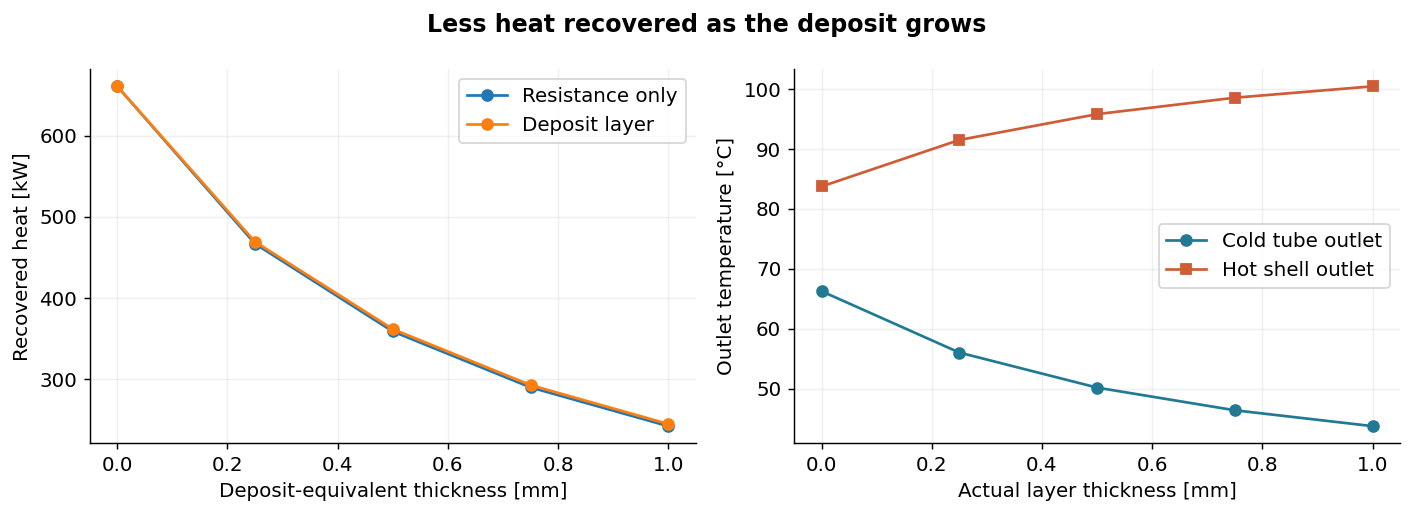

At 1.0 mm, recovered heat falls from **660.7 to 244.6 kW** (63.0% loss). The tube outlet drops from **66.3 to 43.7 °C**. The hot outlet rises because less heat is removed.

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for model, group in results.groupby("Model", sort=False):
    axes[0].plot(group["Layer [mm]"], group["Recovery [kW]"], "o-", label=model)
axes[0].set(xlabel="Deposit-equivalent thickness [mm]", ylabel="Recovered heat [kW]")
axes[0].legend()
axes[1].plot(layer_results["Layer [mm]"], layer_results["Tube outlet [°C]"], "o-",
             color=COLORS["cold"], label="Cold tube outlet")
axes[1].plot(layer_results["Layer [mm]"], layer_results["Shell outlet [°C]"], "s-",
             color=COLORS["heat"], label="Hot shell outlet")
axes[1].set(xlabel="Actual layer thickness [mm]", ylabel="Outlet temperature [°C]")
axes[1].legend()
figure.suptitle("Less heat recovered as the deposit grows", weight="bold")
plt.tight_layout()
plt.show()
last = layer_results.iloc[-1]
display(Markdown(
    f"At 1.0 mm, recovered heat falls from **{clean['Recovery [kW]']:.1f} to "
    f"{last['Recovery [kW]']:.1f} kW** "
    f"({100 * (1 - last['Recovery [kW]'] / clean['Recovery [kW]']):.1f}% loss). "
    f"The tube outlet drops from **{clean['Tube outlet [°C]']:.1f} to "
    f"{last['Tube outlet [°C]']:.1f} °C**. The hot outlet rises because less heat is removed."
))

For these inputs, deposit conduction dominates the improved internal film caused by higher
velocity. The resistance-only and layer curves differ because the latter also changes film area
and convection. Do not interpret their proximity as evidence that hydraulic blockage is negligible;
check pressure loss independently.

Tube ΔP increase at 1 mm: 60.8%
Additional trim heating: 416.0 kW


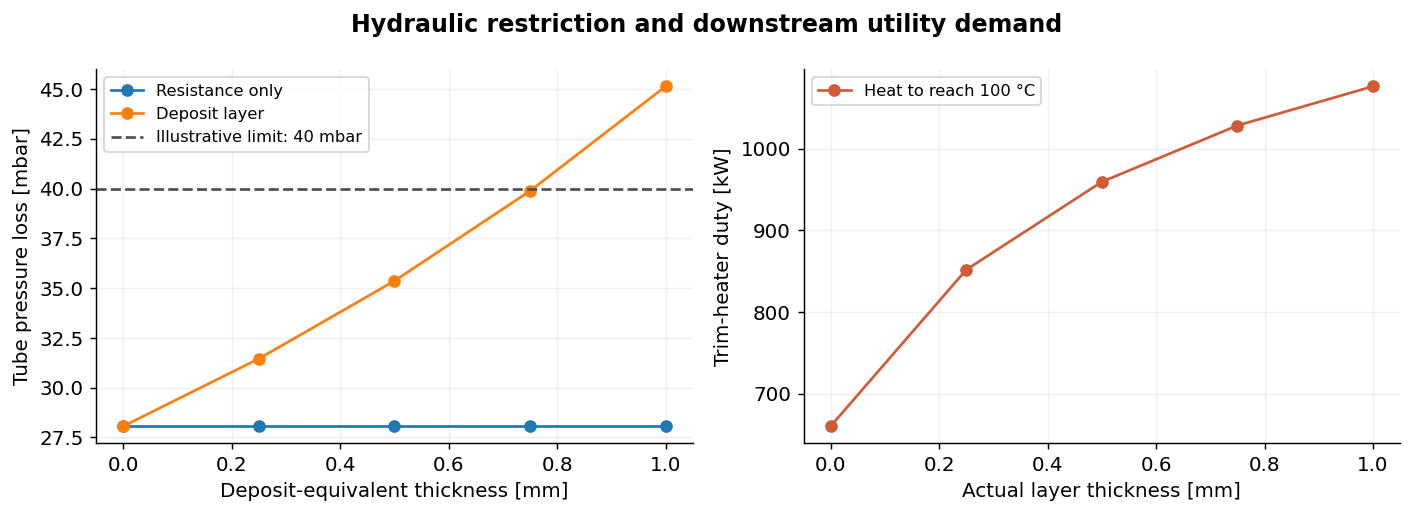

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for model, group in results.groupby("Model", sort=False):
    axes[0].plot(group["Layer [mm]"], group["Tube ΔP [bar]"] * 1000.0, "o-", label=model)
axes[0].axhline(40.0, color="#505050", linestyle="--", label="Illustrative limit: 40 mbar")
axes[0].set(xlabel="Deposit-equivalent thickness [mm]", ylabel="Tube pressure loss [mbar]")
axes[0].legend(fontsize=9)
axes[1].plot(layer_results["Layer [mm]"], layer_results["Trim heat [kW]"], "o-",
             color=COLORS["heat"], label="Heat to reach 100 °C")
axes[1].set(xlabel="Actual layer thickness [mm]", ylabel="Trim-heater duty [kW]")
axes[1].legend(fontsize=9)
figure.suptitle("Hydraulic restriction and downstream utility demand", weight="bold")
plt.tight_layout()
plt.show()
pressure_increase_pct = 100 * (last["Tube ΔP [bar]"] / clean["Tube ΔP [bar]"] - 1)
print(f"Tube ΔP increase at 1 mm: {pressure_increase_pct:.1f}%")
print(f"Additional trim heating: {last['Trim heat [kW]'] - clean['Trim heat [kW]']:.1f} kW")

The resistance-only cases retain the same bore and therefore the same inlet-property pressure
loss. The layer cases narrow the bore and increase pressure loss. The displayed 40 mbar limit is
an illustrative screening constraint, not a vendor or plant limit. The trim heater supplies the
missing sensible heat; a separately configured column is needed to assess separation and reboiler
changes.

## 5. Conservation, reruns and cleaning

Check the numerical result, not just that a calculation completed. We check both component and
mass conservation, the hot/cold enthalpy balance, monotonic trends for this selected low-conductivity
deposit, and reproducibility after rerunning and cleaning. A 0.01 W absolute floor accommodates
small liquid PH-flash residuals near zero duty.

In [10]:
assert results["Mass error [kg/s]"].max() < 1e-9
assert results["Component error [mol/s]"].max() < 1e-9
energy_limits = np.maximum(0.01, results["Recovery [kW]"] * 1000.0 * 1e-5)
assert (results["Energy residual [W]"].abs() < energy_limits).all()
assert np.all(np.diff(layer_results["Recovery [kW]"]) < 0.0)
assert np.all(np.diff(layer_results["Tube ΔP [bar]"]) > 0.0)
resistance_pressure = results.loc[results["Model"] == "Resistance only", "Tube ΔP [bar]"]
np.testing.assert_allclose(resistance_pressure, resistance_pressure.iloc[0], rtol=1e-12)

calculator.setFoulingTube(0.0)
calculator.setTubeFoulingLayer(0.001, 0.2)
process.run()
first_duty = exchanger.getDuty()
first_pressure = exchanger.getOutStream(0).getPressure()
process.run()
np.testing.assert_allclose(exchanger.getDuty(), first_duty, rtol=1e-10)
np.testing.assert_allclose(exchanger.getOutStream(0).getPressure(), first_pressure, atol=1e-10)
calculator.setTubeFoulingLayer(0.0, 0.2)
process.run()
np.testing.assert_allclose(exchanger.getDuty() / 1000.0, clean["Recovery [kW]"], rtol=1e-10)
print("PASS: mass, component, energy, trend, pressure mapping, rerun and cleaning checks")
print(f"Maximum exchanger energy residual: {results['Energy residual [W]'].abs().max():.6f} W")
print(f"Recovered clean duty after cleaning: {exchanger.getDuty() / 1000.0:.3f} kW")

PASS: mass, component, energy, trend, pressure mapping, rerun and cleaning checks
Maximum exchanger energy residual: 0.000980 W
Recovered clean duty after cleaning: 660.685 kW


## 6. A cleaning campaign as sequential steady states

Assume 0.0125 mm/day deposit growth and complete cleaning every 60 days. These are user-specified
scenario inputs, not a fitted kinetic law. Each time sample runs the entire native process.
The example illustrates a potential monitoring calculation; it does not predict a cleaning date
without calibrated deposition and operating data.

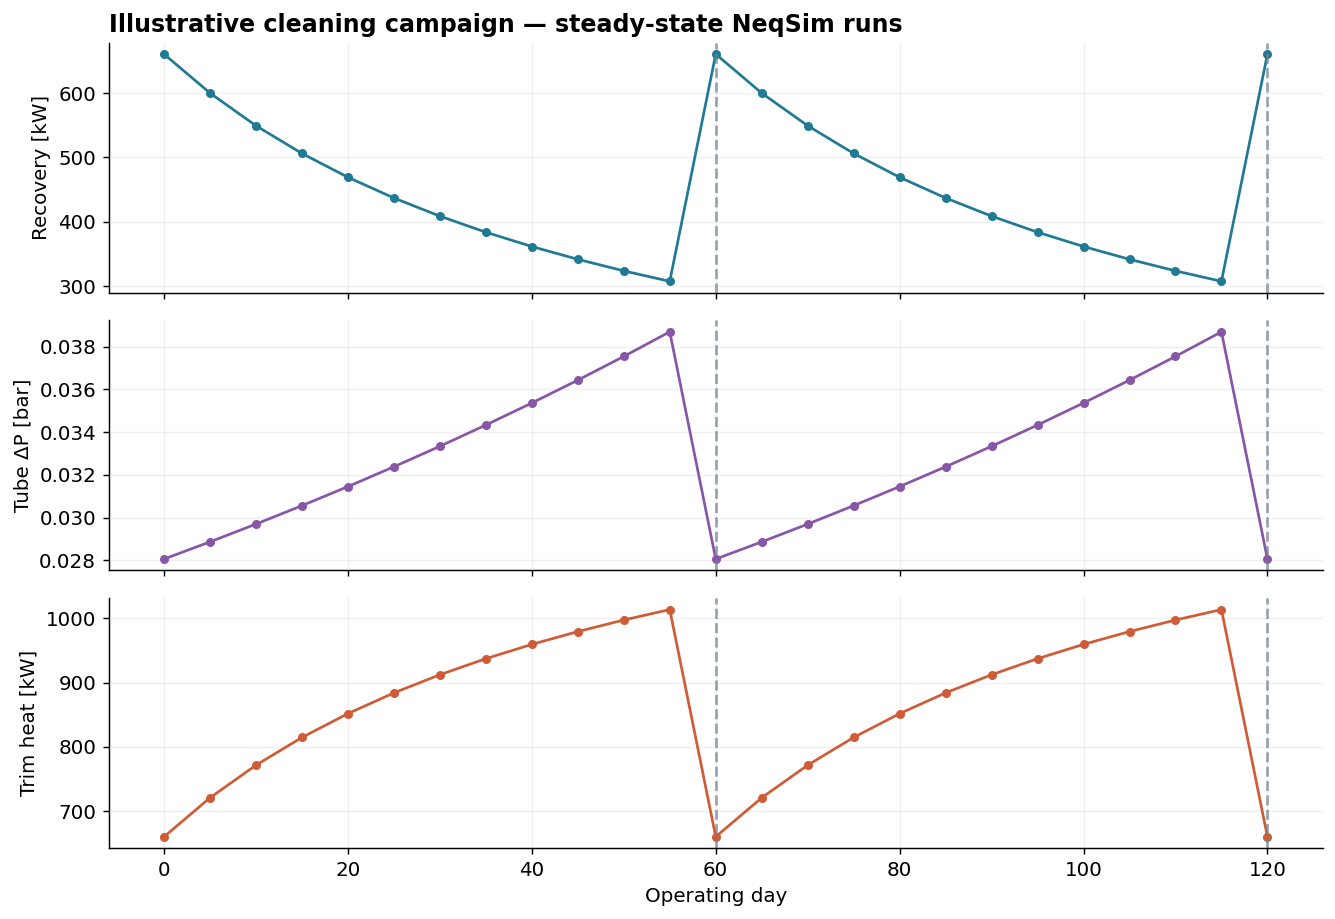

,Day,Layer [mm],Recovery [kW],Tube ΔP [bar],Trim heat [kW]
0,0,0.0000,660.6854,0.0281,660.2017
11,55,0.6875,307.3977,0.0387,1013.4826
12,60,0.0000,660.6854,0.0281,660.2017
23,115,0.6875,307.3977,0.0387,1013.4826
24,120,0.0000,660.6854,0.0281,660.2017


In [11]:
campaign_rows = []
for day in np.arange(0, 121, 5):
    age_days = float(day % 60)
    thickness_mm = 0.0125 * age_days
    calculator.setTubeFoulingLayer(thickness_mm / 1000.0, 0.2)
    process.run()
    row = snapshot(f"Day {day}", thickness_mm, "Scheduled deposit")
    row["Day"] = int(day)
    campaign_rows.append(row)
campaign = pd.DataFrame(campaign_rows)
figure, axes = plt.subplots(3, 1, figsize=(10.5, 7.2), sharex=True)
for axis, column, color in [
    (axes[0], "Recovery [kW]", COLORS["cold"]),
    (axes[1], "Tube ΔP [bar]", COLORS["deposit"]),
    (axes[2], "Trim heat [kW]", COLORS["heat"]),
]:
    axis.plot(campaign["Day"], campaign[column], "o-", color=color, markersize=4)
    axis.set_ylabel(column)
    for cleaning_day in [60, 120]:
        axis.axvline(cleaning_day, color="#708090", linestyle="--", alpha=0.7)
axes[0].set_title("Illustrative cleaning campaign — steady-state NeqSim runs", loc="left")
axes[-1].set_xlabel("Operating day")
plt.tight_layout()
plt.show()
display(campaign.loc[campaign["Day"].isin([0, 55, 60, 115, 120]),
                     ["Day", "Layer [mm]", "Recovery [kW]",
                      "Tube ΔP [bar]", "Trim heat [kW]"]].round(4))

The discontinuities at days 60 and 120 represent an imposed complete cleaning event. Duty and
pressure loss return to their clean values because nominal geometry is preserved. The gradual
segments follow the assumed deposit schedule; they are not transient heat-capacity dynamics.
For monitoring, replace the schedule with measured thickness or a calibrated growth model.

## 7. Conductivity uncertainty and an operating constraint

Deposit thickness and conductivity cannot be inferred independently from heat duty alone. Sweep
conductivity from 0.1 to 0.5 W/(m K) and thickness from 0 to 1 mm, retaining the same process.
The synthetic screening targets are at least 350 kW recovered heat and no more than 0.04 bar tube
pressure loss. Conductivity is a scenario range, not a measured distribution.

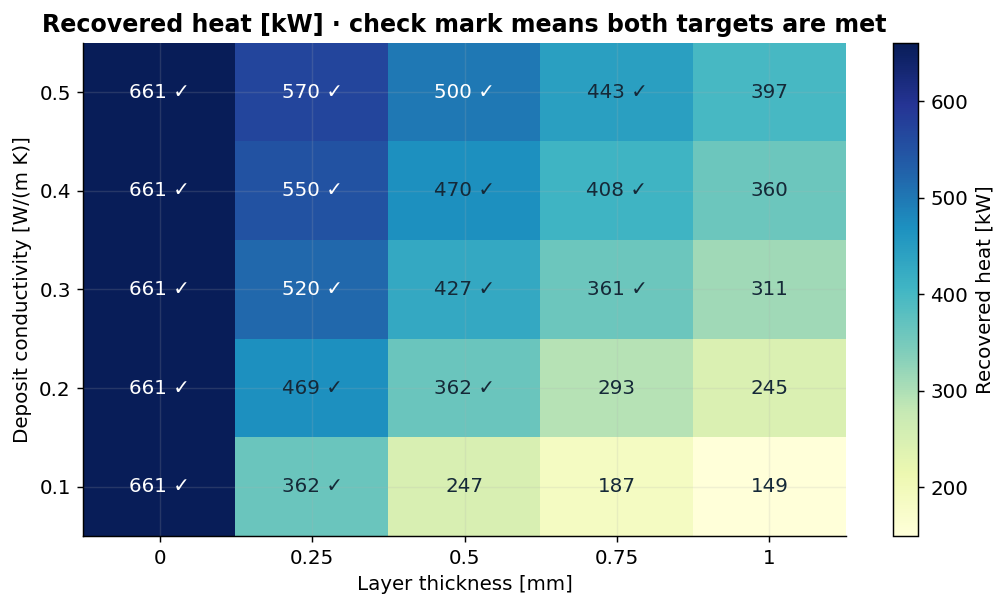

,Largest passing grid thickness [mm]
Conductivity [W/(m K)],
0.1,0.25
0.2,0.50
0.3,0.75
0.4,0.75
0.5,0.75


In [12]:
sensitivity_rows = []
for conductivity in [0.1, 0.2, 0.3, 0.4, 0.5]:
    for thickness_mm in [0.0, 0.25, 0.5, 0.75, 1.0]:
        calculator.setTubeFoulingLayer(thickness_mm / 1000.0, conductivity)
        process.run()
        row = snapshot("Sensitivity", thickness_mm, "Deposit layer")
        row["Conductivity [W/(m K)]"] = conductivity
        row["Meets targets"] = row["Recovery [kW]"] >= 350.0 and row["Tube ΔP [bar]"] <= 0.04
        sensitivity_rows.append(row)
sensitivity = pd.DataFrame(sensitivity_rows)
heat_grid = sensitivity.pivot(index="Conductivity [W/(m K)]", columns="Layer [mm]",
                              values="Recovery [kW]")
feasible_grid = sensitivity.pivot(index="Conductivity [W/(m K)]", columns="Layer [mm]",
                                  values="Meets targets")
figure, axis = plt.subplots(figsize=(8.2, 4.8))
mesh = axis.imshow(heat_grid.values, origin="lower", aspect="auto", cmap="YlGnBu")
for row_index in range(5):
    for column_index in range(5):
        value = heat_grid.iloc[row_index, column_index]
        marker = " ✓" if feasible_grid.iloc[row_index, column_index] else ""
        axis.text(column_index, row_index, f"{value:.0f}{marker}", ha="center", va="center",
                  color="white" if value > 480.0 else "#152938", fontsize=11)
axis.set_xticks(range(5), [f"{value:g}" for value in heat_grid.columns])
axis.set_yticks(range(5), [f"{value:g}" for value in heat_grid.index])
axis.set(xlabel="Layer thickness [mm]", ylabel="Deposit conductivity [W/(m K)]",
         title="Recovered heat [kW] · check mark means both targets are met")
figure.colorbar(mesh, ax=axis, label="Recovered heat [kW]")
plt.tight_layout()
plt.show()
feasible = sensitivity[sensitivity["Meets targets"]]
display(feasible.groupby("Conductivity [W/(m K)]")["Layer [mm]"].max()
        .rename("Largest passing grid thickness [mm]").to_frame())

A thermally conductive deposit can retain more heat duty while still narrowing the bore. At a
fixed thickness the hydraulic result is independent of the assumed deposit conductivity because
this model evaluates fluid transport properties at the same inlet states. The largest passing
thicknesses are grid results, not continuously optimized limits. Refine the grid and use measured
limits before applying the workflow to an asset.

## 8. Reusable outputs and conclusions

The calculated tables can be reused for monitoring or a broader flowsheet. `process`, `exchanger`,
`calculator` and `trim_heater` are live Java objects; their streams can be connected to other native
NeqSim units. The following cell saves the tabular results while retaining all key results inline.

In [13]:
output_dir = Path("fouling_preheater_results")
output_dir.mkdir(exist_ok=True)
results.to_csv(output_dir / "fouling_cases.csv", index=False)
campaign.to_csv(output_dir / "cleaning_campaign.csv", index=False)
sensitivity.to_csv(output_dir / "conductivity_sensitivity.csv", index=False)
extra_heat_kw = last["Trim heat [kW]"] - clean["Trim heat [kW]"]
summary = pd.DataFrame({
    "Metric": ["Clean recovered heat", "Recovered heat at 1 mm", "Extra feed heating at 1 mm",
               "Clean tube pressure loss", "Tube pressure loss at 1 mm"],
    "Value": [clean["Recovery [kW]"], last["Recovery [kW]"], extra_heat_kw,
              clean["Tube ΔP [bar]"], last["Tube ΔP [bar]"]],
    "Unit": ["kW", "kW", "kW", "bar", "bar"],
})
display(summary.round(5))
print("CSV results:", output_dir.resolve())
print("Validation passed: analytical references, conservation, reruns, cleaning and trends.")

CSV results: /workspace/scratch/f6f9de88e67f/fouling_preheater_results
Validation passed: analytical references, conservation, reruns, cleaning and trends.


,Metric,Value,Unit
0,Clean recovered heat,660.68544,kW
1,Recovered heat at 1 mm,244.63177,kW
2,Extra feed heating at 1 mm,416.04267,kW
3,Clean tube pressure loss,0.02806,bar
4,Tube pressure loss at 1 mm,0.04514,bar


The model now links a physical tube deposit to heat recovery, native outlet pressure and downstream
utility duty. Resistance-only fouling remains useful when thermal data are available, but it cannot
by itself predict hydraulic restriction.

**Validation coverage:** exact cylindrical conduction and laminar hydraulics; single-phase
component/mass/enthalpy conservation; pressure mapping; repeated execution and cleaning. Java
regressions additionally reject blocked bores, invalid geometry, exhausted pressure budgets and
phase-transition endpoints. The source implementation preserves the default thermal-only behavior.

**Remaining research task:** obtain the paper's full input tables and any supplementary data before
adding an Aspen-case or experimental benchmark to issue #3718. Temperature-dependent distributed
rating, deposit roughness, shell blockage, fouling kinetics and explicit column separation effects
need additional model qualification.

**Exercises:** replace synthetic properties with a documented fluid; compare the Kern and
Bell–Delaware shell methods; refine the operating-limit grid; connect the preheated stream to a
column model with fixed separation targets and compare its reboiler and condenser duties.